# Создание своего набора данных

## Парсер

In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime

CLIENT_ID     = 'U99BMBT7LMGCN69E0TT3SU1HHGO1MLFNMA364339DPB8D23T4MO76H2MN7KGDAHO'
CLIENT_SECRET = 'KUKO7H716P1I21CUVLS6NBBIF2IUAS7OU23L5P4BEN2BUIIAV003T7HQ7PERDAVT'

# Получаем токен
token_resp = requests.post('https://hh.ru/oauth/token', data={
    'grant_type':    'client_credentials',
    'client_id':     CLIENT_ID,
    'client_secret': CLIENT_SECRET,
})
ACCESS_TOKEN = token_resp.json()['access_token']
print('Токен получен:', ACCESS_TOKEN[:10], '...')

BASE_URL = 'https://api.hh.ru/vacancies'
HEADERS  = {
    'Authorization': f'Bearer {ACCESS_TOKEN}',
    'User-Agent':    'hh-dataset/1.0',
}

# Москва, СПб, Екатеринбург, Новосибирск, Казань
AREAS      = [1, 2, 3, 4, 88]
PER_PAGE   = 100
MAX_PAGES  = 20
TARGET     = 5500

def fetch_page(area_id, page):
    params = {'area': area_id, 'per_page': PER_PAGE, 'page': page}
    r = requests.get(BASE_URL, headers=HEADERS, params=params)
    if r.status_code != 200:
        print(f'  Ошибка {r.status_code}')
        return []
    return r.json().get('items', [])

def parse_vacancy(v):
    salary   = v.get('salary') or {}
    pub_date = datetime.fromisoformat(v['published_at'].replace('Z', '+00:00'))
    roles    = v.get('professional_roles', [])
    return {
        'id':                v['id'],
        'title':             v['name'],
        'city':              v['area']['name'],
        # ЦЕЛЕВАЯ ПЕРЕМЕННАЯ
        'experience':        v['experience']['id'] if v.get('experience') else None,
        # ПРИЗНАКИ
        'employment':        v['employment']['id'] if v.get('employment') else None,
        'schedule':          v['schedule']['id'] if v.get('schedule') else None,
        'salary_from':       salary.get('from'),
        'salary_to':         salary.get('to'),
        'salary_currency':   salary.get('currency'),
        'has_salary':        int(bool(salary)),
        'salary_gross':      int(salary.get('gross', False) or False),
        'is_premium':        int(v.get('premium', False)),
        'employer_trusted':  int(v.get('employer', {}).get('trusted', False)),
        'has_address':       int(v.get('address') is not None),
        'role_id':           roles[0]['id'] if roles else None,
        'published_weekday': pub_date.weekday(),
        'published_hour':    pub_date.hour,
        'title_word_count':  len(v['name'].split()),
    }

all_records = {}

for area_id in AREAS:
    print(f'\nРегион {area_id}...')
    for page in range(MAX_PAGES):
        items = fetch_page(area_id, page)
        if not items:
            break
        for v in items:
            if v['id'] not in all_records:
                all_records[v['id']] = parse_vacancy(v)
        print(f'  стр {page+1:02d}/20 → всего: {len(all_records)}')
        time.sleep(0.3)
        if len(all_records) >= TARGET:
            break
    if len(all_records) >= TARGET:
        break

df_raw = pd.DataFrame(all_records.values())
print(f'\nИтого: {len(df_raw)} вакансий')
df_raw.to_csv('hh_vacancies.csv', index=False)
print('Сохранено → hh_vacancies.csv')

Токен получен: APPLJ6EFR4 ...

Регион 1...
  стр 01/20 → всего: 100
  стр 02/20 → всего: 200
  стр 03/20 → всего: 262
  стр 04/20 → всего: 362
  стр 05/20 → всего: 462
  стр 06/20 → всего: 562
  стр 07/20 → всего: 662
  стр 08/20 → всего: 762
  стр 09/20 → всего: 862
  стр 10/20 → всего: 962
  стр 11/20 → всего: 1013
  стр 12/20 → всего: 1113
  стр 13/20 → всего: 1213
  стр 14/20 → всего: 1261
  стр 15/20 → всего: 1361
  стр 16/20 → всего: 1461
  стр 17/20 → всего: 1561
  стр 18/20 → всего: 1661
  стр 19/20 → всего: 1761
  стр 20/20 → всего: 1861

Регион 2...
  стр 01/20 → всего: 1961
  стр 02/20 → всего: 2049
  стр 03/20 → всего: 2148
  стр 04/20 → всего: 2248
  стр 05/20 → всего: 2346
  стр 06/20 → всего: 2446
  стр 07/20 → всего: 2545
  стр 08/20 → всего: 2630
  стр 09/20 → всего: 2730
  стр 10/20 → всего: 2830
  стр 11/20 → всего: 2930
  стр 12/20 → всего: 3030
  стр 13/20 → всего: 3130
  стр 14/20 → всего: 3230
  стр 15/20 → всего: 3330
  стр 16/20 → всего: 3430
  стр 17/20 → всег

# Цели и правила разметки

**Цель сбора датасета:** предсказать требуемый уровень опыта работы
для вакансии на основе её характеристик.

**Обоснование выбранных параметров (почему собирались именно они):**

* **Целевая переменная:**
  - experience — требуемый опыт (4 класса):

        noExperience — без опыта
        between1And3 — от 1 до 3 лет
        between3And6 — от 3 до 6 лет
        moreThan6 — более 6 лет
      Присутствует в каждой вакансии

* **Признаки / изображения / тексты**

  *   title (отражает уровень должности: junior/senior)
  *   city (город: рынок труда различается по регионам)
  *   employment (тип занятости: полная, частичная, проектная)
  *   schedule (график: удалённый, полный день и др.)
  *   salary_from/to ("вилка" зарплаты: косвенно отражает уровень)
  *   has_salary (указана ли зарплата или нет)
  *   salary_gross (зарплата до или после налогов)
  *   is_premium (платное продвижение вакансии)
  *   employer_trusted (верифицирован ли работодатель)
  *   has_address (указан ли физический адрес офиса)
  *   role_id (профессиональная роль (категория должности))
  *   published_weekday (день недели публикации)
  *   published_hour (час публикации, паттерны HR-активности)
  *   title_word_count (количество слов в названии вакансии)

* **Правила сбора:**

  *  Данные получены через официальный API hh.ru с OAuth авторизацией
  *  Собраны вакансии из 5 крупных городов России для разнообразия
  *  Дублирующиеся вакансии удалены по уникальному id
  *  Вакансии без значения experience исключены из обучения


## Импорт библиотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

SEED = 42
print('Готово.')

Готово.


## Пример данных

Размер: 5573 строк × 18 столбцов



,id,title,city,experience,employment,schedule,salary_from,salary_to,salary_currency,has_salary,salary_gross,is_premium,employer_trusted,has_address,role_id,published_weekday,published_hour,title_word_count
0,131668391,Продавец-кассир,Москва,noExperience,NaN,NaN,61000.0,84383.0,RUR,1,1,0,1,1,97,4,12,1
1,132058576,"Продавец на лето (ТЦ Город Косино, м. Косино)",Москва,noExperience,NaN,NaN,60000.0,69000.0,RUR,1,1,0,1,1,97,4,12,8
2,133650930,Бизнес-аналитик 1С:ERP УСО,Москва,between3And6,NaN,NaN,NaN,NaN,NaN,0,0,0,1,1,10,4,12,3
3,133650929,Продавец-кассир (Аутлет Белая дача ),Москва,between1And3,NaN,NaN,100000.0,NaN,RUR,1,0,0,1,1,97,4,12,5
4,133650925,Юрист по корпоративному праву,Москва,between3And6,NaN,NaN,NaN,NaN,NaN,0,0,0,1,1,146,4,12,4



Пропуски:
id                      0
title                   0
city                    0
experience              0
employment           5573
schedule             5573
salary_from          1161
salary_to            3026
salary_currency       920
has_salary              0
salary_gross            0
is_premium              0
employer_trusted        0
has_address             0
role_id                 0
published_weekday       0
published_hour          0
title_word_count        0
dtype: int64

Распределение классов:
experience
1–3 года       2654
Без опыта      1788
3–6 лет         956
Более 6 лет     175
Name: count, dtype: int64


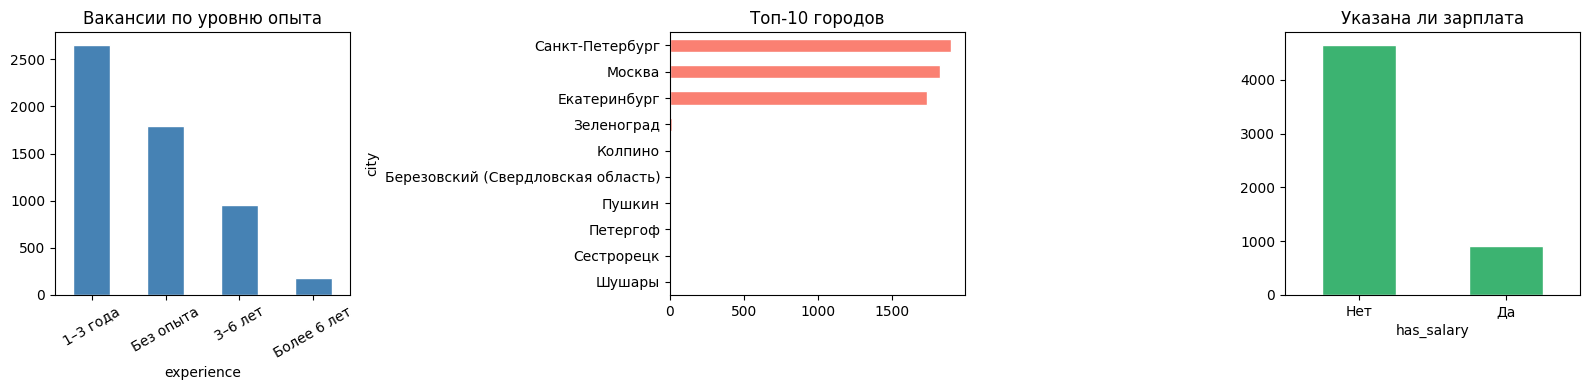

In [ ]:
df = pd.read_csv('hh_vacancies.csv')

print(f'Размер: {df.shape[0]} строк × {df.shape[1]} столбцов\n')
display(df.head())

print('\nПропуски:')
print(df.isnull().sum())

exp_map = {
    'noExperience': 'Без опыта',
    'between1And3': '1–3 года',
    'between3And6': '3–6 лет',
    'moreThan6':    'Более 6 лет',
}
counts = df['experience'].map(exp_map).value_counts()
print('\nРаспределение классов:')
print(counts)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

counts.plot.bar(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Вакансии по уровню опыта')
axes[0].tick_params(axis='x', rotation=30)

df['city'].value_counts().head(10).plot.barh(ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Топ-10 городов')
axes[1].invert_yaxis()

df['has_salary'].value_counts().plot.bar(ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('Указана ли зарплата')
axes[2].set_xticklabels(['Нет', 'Да'], rotation=0)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120)
plt.show()

## Baseline

Подготовка данных

Строк: 5573
Классы: ['between1And3', 'between3And6', 'moreThan6', 'noExperience']
Train: 4458  |  Test: 1115

Accuracy:      0.586
F1 (weighted): 0.556
F1 (macro):    0.398

              precision    recall  f1-score   support

between1And3       0.56      0.80      0.66       531
between3And6       0.46      0.20      0.28       191
   moreThan6       1.00      0.03      0.06        35
noExperience       0.69      0.53      0.60       358

    accuracy                           0.59      1115
   macro avg       0.68      0.39      0.40      1115
weighted avg       0.60      0.59      0.56      1115



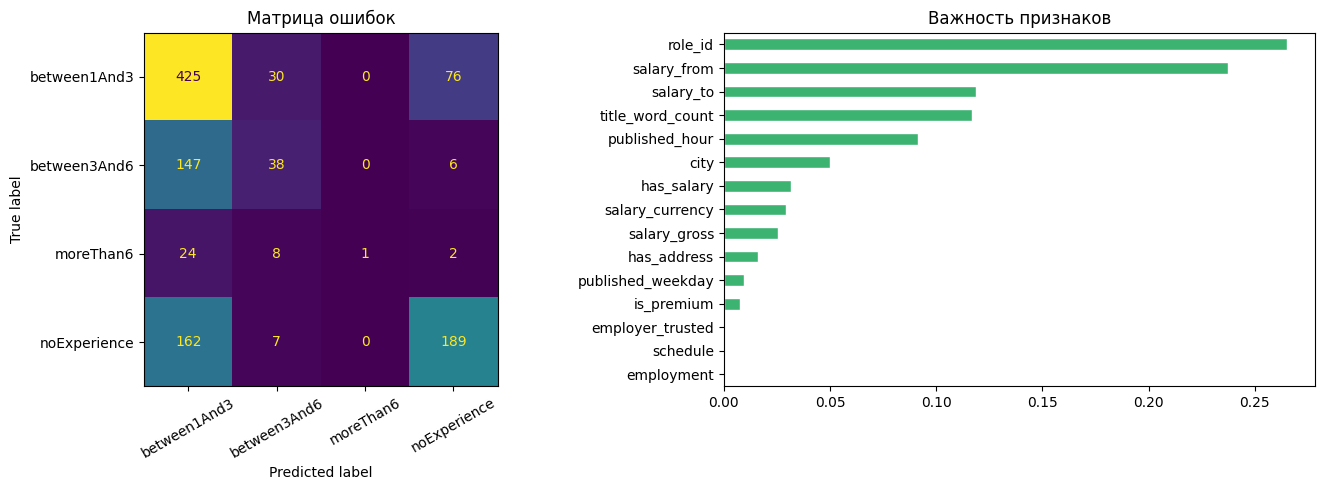

In [ ]:
df_model = df.dropna(subset=['experience']).copy()
print(f'Строк: {len(df_model)}')

CATEGORICAL = ['city', 'employment', 'schedule', 'salary_currency']
NUMERIC     = ['salary_from', 'salary_to', 'title_word_count',
               'published_weekday', 'published_hour', 'role_id']
BINARY      = ['has_salary', 'salary_gross', 'is_premium',
               'employer_trusted', 'has_address']

df_model[NUMERIC]     = df_model[NUMERIC].fillna(-1)
df_model[CATEGORICAL] = df_model[CATEGORICAL].fillna('unknown')
df_model[BINARY]      = df_model[BINARY].fillna(0).astype(int)

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_model[CATEGORICAL] = enc.fit_transform(df_model[CATEGORICAL])

le = LabelEncoder()
y  = le.fit_transform(df_model['experience'])
print('Классы:', list(le.classes_))

FEATURES = CATEGORICAL + NUMERIC + BINARY
X = df_model[FEATURES]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')

clf = RandomForestClassifier(
    n_estimators=300, max_depth=15,
    min_samples_leaf=2, random_state=SEED, n_jobs=-1
)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f'\nAccuracy:      {accuracy_score(y_test, y_pred):.3f}')
print(f'F1 (weighted): {f1_score(y_test, y_pred, average="weighted"):.3f}')
print(f'F1 (macro):    {f1_score(y_test, y_pred, average="macro"):.3f}')
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=le.classes_,
    ax=axes[0], colorbar=False
)
axes[0].set_title('Матрица ошибок')
axes[0].tick_params(axis='x', rotation=30)

pd.Series(clf.feature_importances_, index=FEATURES).sort_values().plot.barh(
    ax=axes[1], color='mediumseagreen', edgecolor='white'
)
axes[1].set_title('Важность признаков')

plt.tight_layout()
plt.savefig('baseline_results.png', dpi=120)
plt.show()

## Как использовать датасет

Собранный массив данных предоставляет основу для задачи
многоклассовой классификации: предсказание требуемого уровня
опыта работы по характеристикам вакансии.

Работа с датасетом предполагает прохождение нескольких этапов:

**Этап 1:** Загрузка
df = pd.read_csv('hh_vacancies.csv')

**Этап 2:** Предобработка
Заполнить пропуски (-1 для числовых, 'unknown' для категориальных),
закодировать категориальные признаки через OrdinalEncoder.

**Этап 3:** Обучение и оценка
Разделить данные 80/20, обучить RandomForestClassifier,
оценить по Accuracy и F1-score (weighted).

**Структура файла hh_vacancies.csv:**
- id                : уникальный ID вакансии на hh.ru
- title             : название вакансии
- city              : город
- experience        : ЦЕЛЕВАЯ ПЕРЕМЕННАЯ (4 класса)
- employment        : тип занятости
- schedule          : график работы
- salary_from       : минимум зарплатной вилки (руб.)
- salary_to         : максимум зарплатной вилки (руб.)
- salary_currency   : валюта
- has_salary        : указана ли зарплата (0/1)
- salary_gross      : зарплата до вычета налогов (0/1)
- is_premium        : платное продвижение (0/1)
- employer_trusted  : верифицированный работодатель (0/1)
- has_address       : указан физический адрес (0/1)
- role_id           : ID профессиональной роли
- published_weekday : день недели публикации (0=пн)
- published_hour    : час публикации
- title_word_count  : количество слов в названии